In [12]:
import pandas as pd
import requests
from io import StringIO
from tqdm import tqdm
import os

# ============================================
# OPTION 1: Download from USGS API (Recommended)
# ============================================
def download_usgs_catalog(starttime="2010-01-01", endtime="2026-04-23",
                          minlatitude=-10, maxlatitude=10,
                          minlongitude=95, maxlongitude=140,
                          minmagnitude=3.0, filename="data/raw/indonesia_earthquakes.csv"):

    os.makedirs("data/raw", exist_ok=True)

    url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
    params = {
        "format": "csv",
        "starttime": starttime,
        "endtime": endtime,
        "minlatitude": minlatitude,
        "maxlatitude": maxlatitude,
        "minlongitude": minlongitude,
        "maxlongitude": maxlongitude,
        "minmagnitude": minmagnitude,
        "orderby": "time-asc",
        "limit": 20000,   # Corrected: Max per call is 20k
    }

    print("Downloading from USGS...")
    response = requests.get(url, params=params)

    if response.status_code == 200:
        df = pd.read_csv(StringIO(response.text))
        df.to_csv(filename, index=False)
        print(f" Saved {len(df)} events to {filename}")
        return df
    else:
        print(" Download failed. Status:", response.status_code)
        return None



if __name__ == "__main__":

    df = download_usgs_catalog(
        starttime="2010-01-01",
        endtime="2026-04-23",
        minlatitude=-10,
        maxlatitude=10,
        minlongitude=95,
        maxlongitude=140,
        minmagnitude=3.5,
        filename="data/raw/indonesia_earthquakes_2010_2026.csv"
    )




    print("\n=== Dataset Info ===")
    print(df.info())
    print("\n=== First 5 rows ===")
    print(df.head())
    print("\n=== Basic Statistics ===")
    print(df[['mag', 'depth', 'latitude', 'longitude']].describe())

    print("\n=== Magnitude Distribution ===")
    print(df['mag'].value_counts().sort_index().head(10))

 Saved 20000 events to data/raw/indonesia_earthquakes_2010_2026.csv

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             20000 non-null  object 
 1   latitude         20000 non-null  float64
 2   longitude        20000 non-null  float64
 3   depth            20000 non-null  float64
 4   mag              20000 non-null  float64
 5   magType          20000 non-null  object 
 6   nst              5418 non-null   float64
 7   gap              19999 non-null  float64
 8   dmin             14581 non-null  float64
 9   rms              19994 non-null  float64
 10  net              20000 non-null  object 
 11  id               20000 non-null  object 
 12  updated          20000 non-null  object 
 13  place            20000 non-null  object 
 14  type             20000 non-null  object 
 15  horizontalErro

In [13]:
df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2010-01-01T04:42:53.630Z,5.0270,127.1210,80.80,4.4,mb,33.0,117.7,NaN,0.72,...,2014-11-07T01:40:22.538Z,"180 km SE of Pondaguitan, Philippines",earthquake,NaN,10.1,NaN,12.0,reviewed,us,us
1,2010-01-01T17:23:54.720Z,3.6210,126.7800,66.60,4.3,mb,38.0,130.7,NaN,0.95,...,2014-11-07T01:40:22.869Z,"245 km SE of Sarangani, Philippines",earthquake,NaN,12.5,NaN,15.0,reviewed,us,us
2,2010-01-01T18:14:32.220Z,-6.7040,130.0210,161.30,4.8,mb,57.0,54.8,NaN,1.05,...,2014-11-07T01:40:22.947Z,Banda Sea,earthquake,NaN,8.3,NaN,22.0,reviewed,us,us
3,2010-01-01T18:29:45.200Z,-1.9000,101.1360,27.40,4.3,mb,54.0,35.2,NaN,1.43,...,2014-11-07T01:40:22.969Z,"33 km WNW of Sungai Penuh, Indonesia",earthquake,NaN,28.8,NaN,12.0,reviewed,us,us
4,2010-01-02T07:27:04.230Z,-2.1880,134.1260,42.90,4.1,mb,20.0,105.7,NaN,1.07,...,2014-11-07T01:40:23.488Z,"146 km S of Manokwari, Indonesia",earthquake,NaN,25.2,NaN,6.0,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2020-01-18T01:31:10.722Z,-6.5892,132.0980,10.00,5.1,mww,NaN,36.0,1.595,1.00,...,2025-12-22T18:26:37.725Z,"128 km SW of Tual, Indonesia",earthquake,5.0,1.7,0.066,22.0,reviewed,us,us
19996,2020-01-18T01:55:24.824Z,4.6132,95.0658,53.54,4.9,mb,NaN,169.0,1.971,0.80,...,2020-04-08T19:39:34.040Z,"106 km SSW of Banda Aceh, Indonesia",earthquake,6.5,8.0,0.091,38.0,reviewed,us,us
19997,2020-01-18T03:31:18.568Z,0.3013,124.9058,79.11,4.5,mb,NaN,57.0,2.504,0.77,...,2020-04-08T19:39:34.040Z,"111 km S of Tondano, Indonesia",earthquake,7.5,4.0,0.115,22.0,reviewed,us,us
19998,2020-01-18T08:54:10.063Z,5.8733,124.1375,512.43,4.0,mb,NaN,56.0,1.861,0.78,...,2020-04-08T19:40:04.040Z,"36 km SW of Malisbeng, Philippines",earthquake,14.5,10.7,0.139,14.0,reviewed,us,us


In [14]:
df.shape

(20000, 22)

In [15]:
df["mag"].value_counts().sort_values()

mag
7.6       1
7.2       2
7.8       2
7.5       2
7.3       3
6.8       4
3.5       4
7.1       4
6.7       6
7.0       6
3.6       7
6.9       7
6.4       9
6.5      13
6.2      13
6.6      13
3.7      16
3.8      20
6.3      21
6.1      30
6.0      32
3.9      39
5.9      45
5.8      57
5.7      81
5.6      81
5.5     107
5.4     151
5.3     227
5.2     314
5.1     443
5.0     623
4.9     780
4.8     914
4.0    1139
4.7    1359
4.1    1840
4.6    1951
4.5    2267
4.2    2303
4.3    2485
4.4    2579
Name: count, dtype: int64

In [16]:
# After loading df
print("Time range:", df['time'].min(), "→", df['time'].max())
print("Total events:", len(df))
print("Events per year:", len(df) / (2026 - 2010))

# Check for missing values
print(df.isnull().sum())

# Filter only high-quality events (recommended for research)
df_clean = df[df['status'] == 'reviewed'].copy()
df_clean = df_clean.sort_values('time').reset_index(drop=True)

df_clean.isna().sum()

Time range: 2010-01-01T04:42:53.630Z → 2020-01-18T16:38:14.301Z
Total events: 20000
Events per year: 1250.0
time                   0
latitude               0
longitude              0
depth                  0
mag                    0
magType                0
nst                14582
gap                    1
dmin                5419
rms                    6
net                    0
id                     0
updated                0
place                  0
type                   0
horizontalError     7853
depthError          1554
magError            5581
magNst              1540
status                 0
locationSource         0
magSource              0
dtype: int64


time                   0
latitude               0
longitude              0
depth                  0
mag                    0
magType                0
nst                14582
gap                    1
dmin                5419
rms                    6
net                    0
id                     0
updated                0
place                  0
type                   0
horizontalError     7853
depthError          1554
magError            5581
magNst              1540
status                 0
locationSource         0
magSource              0
dtype: int64

In [17]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import os
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')


RAW_PATH = "data/raw/indonesia_earthquakes_2010_2026.csv"
PROCESSED_PATH = "data/processed/indonesia_featured.parquet"
RANDOM_STATE = 42


def clean_data(df):
    print("Step 1: Cleaning data...")

    # Keep only reviewed events (higher quality)
    df = df[df['status'] == 'reviewed'].copy()

    # Convert time to datetime
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').reset_index(drop=True)

    # Remove duplicates
    df = df.drop_duplicates(subset=['id'], keep='first')

    # Filter unrealistic values
    df = df[(df['mag'] >= 3.0) & (df['mag'] <= 9.5)]
    df = df[(df['depth'] >= 0) & (df['depth'] <= 700)]

    # Keep important columns
    keep_cols = ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'place']
    df = df[keep_cols].copy()

    print(f"   Cleaned dataset: {len(df)} events")
    return df


def add_temporal_features(df):
    print("Step 2: Adding temporal features...")

    df['hour'] = df['time'].dt.hour
    df['dayofweek'] = df['time'].dt.dayofweek
    df['month'] = df['time'].dt.month
    df['year'] = df['time'].dt.year

    # Time since previous event (very important)
    df['time_diff'] = df['time'].diff().dt.total_seconds() / 3600  # hours
    df['time_diff'] = df['time_diff'].fillna(0)

    # Days since last event (for longer-term patterns)
    df['days_since_last'] = df['time_diff'] / 24

    return df


def add_spatial_features(df, eps=1.5, min_samples=50):
    """
    Cluster earthquakes into seismic zones using DBSCAN.
    This is crucial for predicting "geographical location".
    """
    print("Step 3: Creating seismic zones with DBSCAN...")

    coords = df[['latitude', 'longitude']].values

    # DBSCAN clustering (good for irregular seismic zones)
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='haversine')
    # Convert to radians for haversine
    coords_rad = np.radians(coords)
    clusters = db.fit_predict(coords_rad)

    df['seismic_zone'] = clusters

    # Number of unique zones
    n_zones = len(set(clusters)) - (1 if -1 in clusters else 0)
    print(f"   Found {n_zones} seismic zones (plus noise points)")

    # Distance to nearest cluster center (for noise points)
    # (Simplified version - you can improve later)
    df['is_noise'] = (df['seismic_zone'] == -1).astype(int)

    return df

def add_statistical_features(df, windows=[7, 30, 90]):
    """
    Add rolling statistical features that seismologists actually use.
    These are the features that give your model real predictive power.
    """
    print("Step 4: Adding statistical precursor features...")

    df = df.sort_values('time').reset_index(drop=True)

    # Cumulative energy release (seismic moment proxy)
    df['energy'] = 10 ** (1.5 * df['mag'])
    df['cumulative_energy'] = df['energy'].cumsum()

    for w in windows:
        # Number of events in last N days
        df[f'events_last_{w}d'] = df.rolling(f'{w}D', on='time')['mag'].count()

        # Mean magnitude in last N days
        df[f'mean_mag_{w}d'] = df.rolling(f'{w}D', on='time')['mag'].mean()

        # Max magnitude in last N days
        df[f'max_mag_{w}d'] = df.rolling(f'{w}D', on='time')['mag'].max()

        # Foreshock count (events in last 7 days before current)
        # (Simplified - can be improved)
        df[f'foreshock_count_{w}d'] = df.rolling(f'{w}D', on='time')['mag'].count() - 1

    # Simple b-value estimate (Gutenberg-Richter law) - rolling
    # b ≈ log10(N) / (Mmax - Mmin)   (approximation)
    df['b_value_30d'] = np.log10(df['events_last_30d'] + 1) / (df['max_mag_30d'] - 3.0 + 0.1)

    return df


def create_sequences(df, seq_length=50, target_days=7):
    """
    Create sequences of past events to predict future events.
    This is what your Transformer will use.
    """
    print(f"Step 5: Creating sequences (seq_length={seq_length}, target={target_days} days)...")

    sequences = []
    targets = []

    for i in range(seq_length, len(df)):
        # Input sequence: last seq_length events
        seq = df.iloc[i-seq_length:i][[
            'mag', 'depth', 'latitude', 'longitude',
            'time_diff', 'energy', 'seismic_zone'
        ]].values

        # Target: Next event within target_days that is M >= 4.5
        future = df.iloc[i:i+100]  # look ahead
        future = future[future['time'] <= df.iloc[i]['time'] + timedelta(days=target_days)]

        if len(future) > 0:
            next_event = future.iloc[0]
            target_mag = next_event['mag']
            target_zone = next_event['seismic_zone']

            sequences.append(seq)
            targets.append({
                'next_mag': target_mag,
                'next_zone': target_zone,
                'has_large_event': 1 if target_mag >= 5.0 else 0
            })

    print(f"   Created {len(sequences)} sequences")
    return np.array(sequences), pd.DataFrame(targets)


if __name__ == "__main__":
    os.makedirs("data/processed", exist_ok=True)

    # Load raw data
    print("Loading raw data...")
    df = pd.read_csv(RAW_PATH)
    print(f"Original size: {len(df)} events")

    # Run pipeline
    df = clean_data(df)
    df = add_temporal_features(df)
    df = add_spatial_features(df, eps=1.2, min_samples=40)   # Adjust eps if needed
    df = add_statistical_features(df)

    # Save cleaned + featured version (before sequences)
    df.to_parquet(PROCESSED_PATH.replace('.parquet', '_featured.parquet'), index=False)
    print(f"\n✅ Saved featured dataset to {PROCESSED_PATH.replace('.parquet', '_featured.parquet')}")

    # Create sequences for model training
    X, y = create_sequences(df, seq_length=60, target_days=7)

    # Save sequences
    np.save("data/processed/X_sequences.npy", X)
    y.to_parquet("data/processed/y_targets.parquet", index=False)

    print("\n=== FINAL DATASET SUMMARY ===")
    print(f"Total events after cleaning: {len(df)}")
    print(f"Number of seismic zones: {df['seismic_zone'].nunique()}")
    print(f"Sequence shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print("\nSample features:", list(df.columns))

Loading raw data...
Original size: 20000 events
Step 1: Cleaning data...
   Cleaned dataset: 20000 events
Step 2: Adding temporal features...
Step 3: Creating seismic zones with DBSCAN...
   Found 1 seismic zones (plus noise points)
Step 4: Adding statistical precursor features...

✅ Saved featured dataset to data/processed/indonesia_featured_featured.parquet
Step 5: Creating sequences (seq_length=60, target=7 days)...
   Created 19940 sequences

=== FINAL DATASET SUMMARY ===
Total events after cleaning: 20000
Number of seismic zones: 1
Sequence shape: (19940, 60, 7)
Target shape: (19940, 3)

Sample features: ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'place', 'hour', 'dayofweek', 'month', 'year', 'time_diff', 'days_since_last', 'seismic_zone', 'is_noise', 'energy', 'cumulative_energy', 'events_last_7d', 'mean_mag_7d', 'max_mag_7d', 'foreshock_count_7d', 'events_last_30d', 'mean_mag_30d', 'max_mag_30d', 'foreshock_count_30d', 'events_last_90d', 'mean_mag_90d', 'max_ma

In [18]:
import pandas as pd
import numpy as np

df = pd.read_parquet("data/processed/indonesia_featured_featured.parquet")
print(df[['mag', 'seismic_zone', 'b_value_30d', 'events_last_30d']].describe())
print("\nTarget distribution:")
print(pd.read_parquet("data/processed/y_targets.parquet")['has_large_event'].value_counts())

                mag  seismic_zone   b_value_30d  events_last_30d
count  20000.000000       20000.0  20000.000000     20000.000000
mean       4.505335           0.0      0.655622       176.115700
std        0.394811           0.0      0.098329        56.125224
min        3.500000           0.0      0.200687         1.000000
25%        4.200000           0.0      0.585484       137.000000
50%        4.400000           0.0      0.649857       165.000000
75%        4.700000           0.0      0.722439       200.000000
max        7.800000           0.0      0.968451       393.000000

Target distribution:
has_large_event
0    17655
1     2285
Name: count, dtype: int64


In [19]:
FEATURED_PATH = "data/processed/indonesia_featured.parquet"
TARGET_PATH = "data/processed/y_targets.parquet"

df.to_parquet(FEATURED_PATH, index=False)

df = pd.read_parquet(FEATURED_PATH)
y = pd.read_parquet(TARGET_PATH)

Loaded 20000 events from: data\processed\indonesia_featured.parquet
Loaded 19940 targets from: data\processed\y_targets.parquet
Number of seismic zones: 1
Saved: figures\magnitude_distribution.png


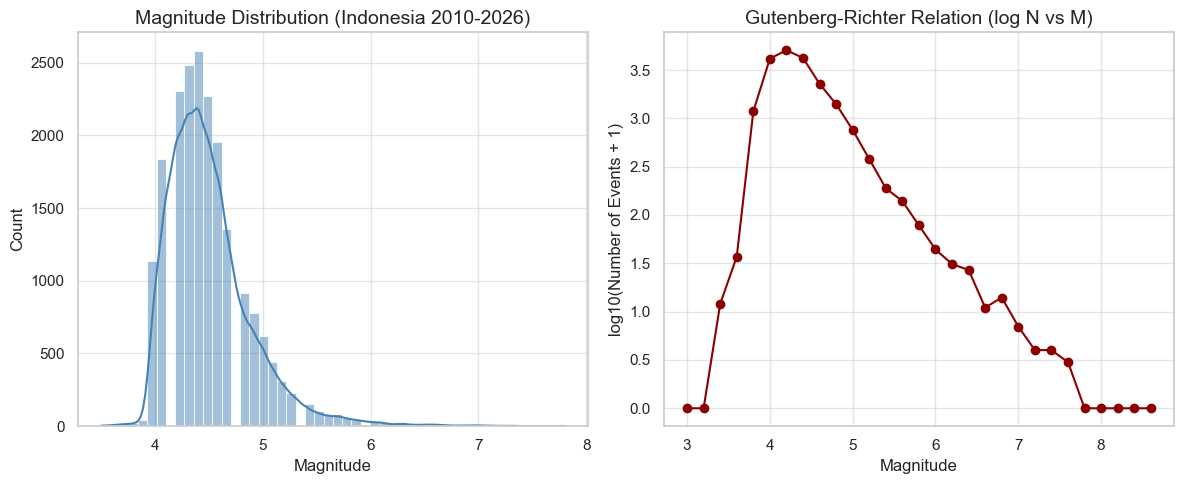

Creating density map...
Saved: figures\indonesia_earthquake_density.html
Saved: figures\seismic_zones_map.png


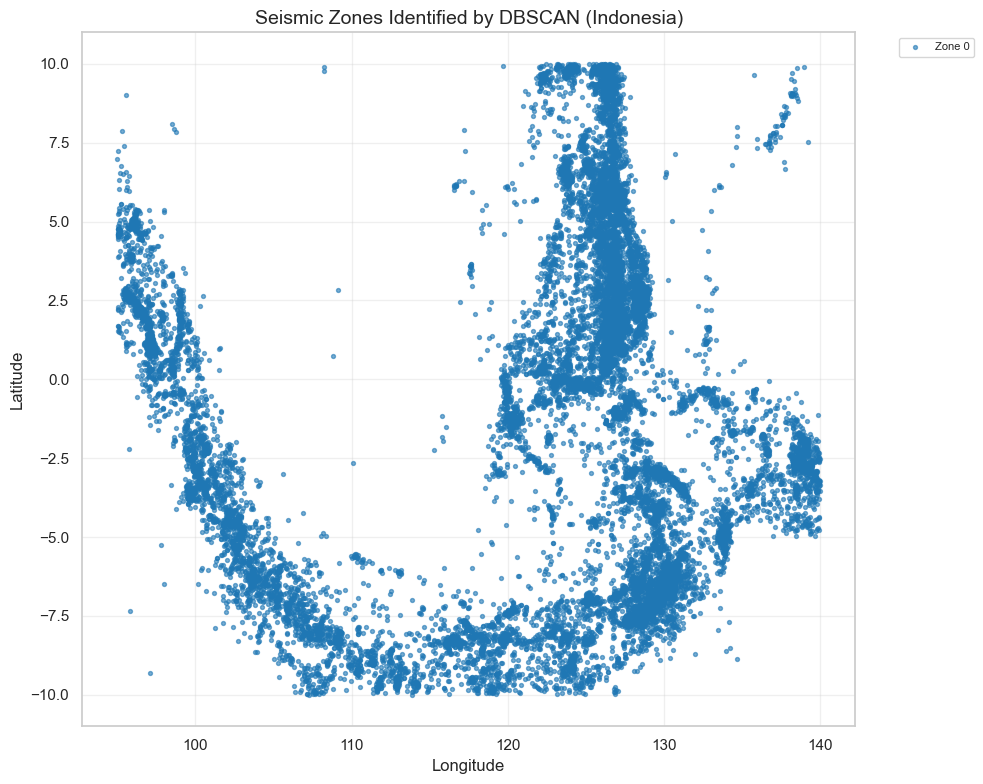

Saved: figures\temporal_patterns.png


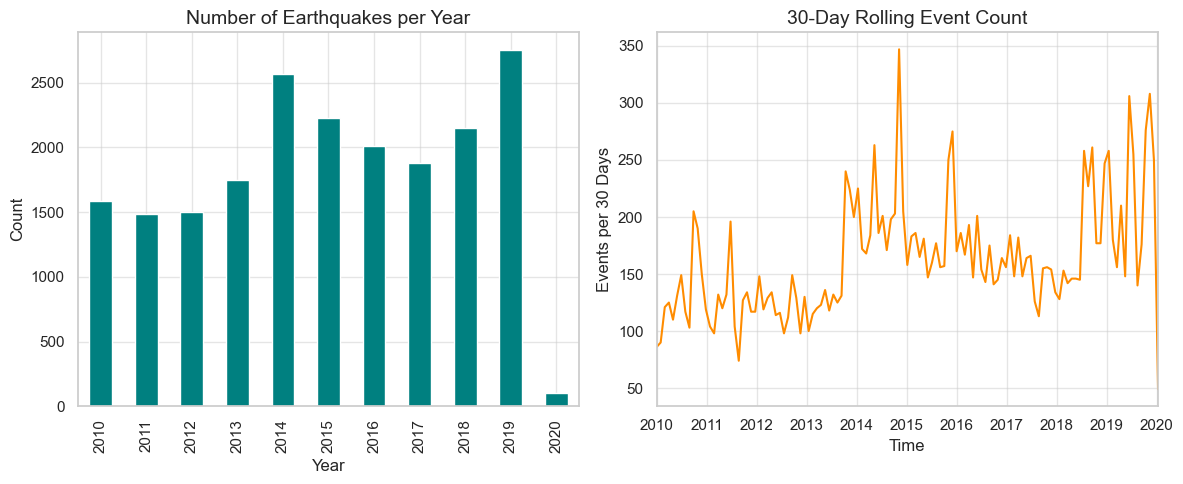

Saved: figures\target_distribution.png


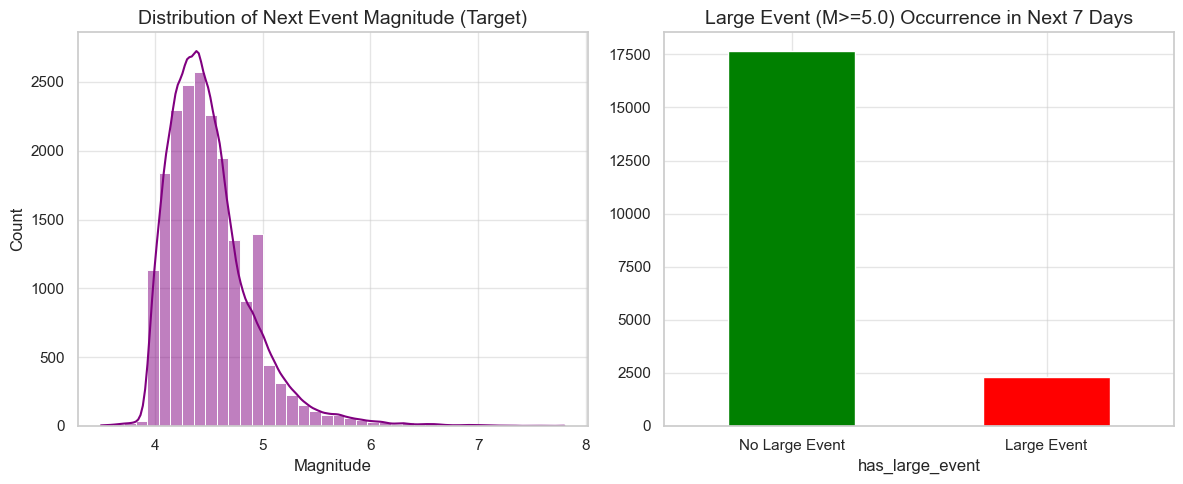


All visualizations saved in the 'figures/' folder.
Files created:
- magnitude_distribution.png
- indonesia_earthquake_density.html
- seismic_zones_map.png
- temporal_patterns.png
- feature_correlation.png
- target_distribution.png


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from pathlib import Path

sns.set_theme(style="whitegrid")

# Paths
BASE_DIR = Path(".")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FEATURED_CANDIDATES = [
    PROCESSED_DIR / "indonesia_featured.parquet",
    PROCESSED_DIR / "indonesia_featured_featured.parquet",
]
TARGET_PATH = PROCESSED_DIR / "y_targets.parquet"

FEATURED_PATH = next((p for p in FEATURED_CANDIDATES if p.exists()), None)

if FEATURED_PATH is None:
    searched = "\n".join(str(p) for p in FEATURED_CANDIDATES)
    raise FileNotFoundError(
        f"Featured dataset not found. Checked:\n{searched}"
    )

if not TARGET_PATH.exists():
    raise FileNotFoundError(f"Target dataset not found: {TARGET_PATH}")

# Load data
df = pd.read_parquet(FEATURED_PATH)
y = pd.read_parquet(TARGET_PATH)

# Ensure time column is datetime
df["time"] = pd.to_datetime(df["time"], errors="coerce")

print(f"Loaded {len(df)} events from: {FEATURED_PATH}")
print(f"Loaded {len(y)} targets from: {TARGET_PATH}")
print(f"Number of seismic zones: {df['seismic_zone'].nunique()}")

def save_plot(filename):
    out_path = FIGURES_DIR / filename
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_path}")

# 1. Magnitude distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df["mag"], bins=50, kde=True, color="steelblue")
plt.title("Magnitude Distribution (Indonesia 2010-2026)", fontsize=14)
plt.xlabel("Magnitude")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
mag_bins = np.arange(3, 9, 0.2)
counts, _ = np.histogram(df["mag"].dropna(), bins=mag_bins)
plt.plot(mag_bins[:-1], np.log10(counts + 1), marker="o", color="darkred")
plt.title("Gutenberg-Richter Relation (log N vs M)", fontsize=14)
plt.xlabel("Magnitude")
plt.ylabel("log10(Number of Events + 1)")

plt.tight_layout()
save_plot("magnitude_distribution.png")
plt.show()

# 2. Density map
print("Creating density map...")

map_df = df[["latitude", "longitude"]].dropna()
sample_df = map_df.sample(n=min(50000, len(map_df)), random_state=42)

m = folium.Map(location=[-2.5, 118], zoom_start=5, tiles="CartoDB positron")
heat_data = sample_df[["latitude", "longitude"]].values.tolist()
HeatMap(heat_data, radius=8, blur=15, max_zoom=10).add_to(m)

map_path = FIGURES_DIR / "indonesia_earthquake_density.html"
m.save(str(map_path))
print(f"Saved: {map_path}")

# 3. Seismic zones map
plt.figure(figsize=(10, 8))

unique_zones = sorted(df["seismic_zone"].dropna().unique())
colors = plt.cm.tab20(np.linspace(0, 1, max(len(unique_zones), 1)))

for i, zone in enumerate(unique_zones):
    zone_data = df[df["seismic_zone"] == zone].dropna(subset=["longitude", "latitude"])
    if zone == -1:
        plt.scatter(
            zone_data["longitude"],
            zone_data["latitude"],
            c="lightgray",
            s=5,
            alpha=0.3,
            label="Noise",
        )
    else:
        plt.scatter(
            zone_data["longitude"],
            zone_data["latitude"],
            c=[colors[i]],
            s=8,
            alpha=0.6,
            label=f"Zone {int(zone)}",
        )

plt.title("Seismic Zones Identified by DBSCAN (Indonesia)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_plot("seismic_zones_map.png")
plt.show()

# 4. Temporal patterns
df["year"] = df["time"].dt.year
yearly = df.groupby("year").size()

plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
yearly.plot(kind="bar", color="teal", ax=ax1)
ax1.set_title("Number of Earthquakes per Year", fontsize=14)
ax1.set_xlabel("Year")
ax1.set_ylabel("Count")

ax2 = plt.subplot(1, 2, 2)
df.set_index("time").resample("30D").size().plot(color="darkorange", ax=ax2)
ax2.set_title("30-Day Rolling Event Count", fontsize=14)
ax2.set_xlabel("Time")
ax2.set_ylabel("Events per 30 Days")

plt.tight_layout()
save_plot("temporal_patterns.png")
plt.show()

# 5. Correlation heatmap
numeric_cols = [
    "mag",
    "depth",
    "latitude",
    "longitude",
    "time_diff",
    "energy",
    "events_last_30d",
    "mean_mag_30d",
    "b_value_30d",
]

available_numeric_cols = [col for col in numeric_cols if col in df.columns]
corr = df[available_numeric_cols].corr()



# 6. Target distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y["next_mag"], bins=40, kde=True, color="purple")
plt.title("Distribution of Next Event Magnitude (Target)", fontsize=14)
plt.xlabel("Magnitude")

plt.subplot(1, 2, 2)
target_counts = y["has_large_event"].value_counts().reindex([0, 1], fill_value=0)
target_counts.plot(kind="bar", color=["green", "red"])
plt.title("Large Event (M>=5.0) Occurrence in Next 7 Days", fontsize=14)
plt.xticks([0, 1], ["No Large Event", "Large Event"], rotation=0)

plt.tight_layout()
save_plot("target_distribution.png")
plt.show()

print("\nAll visualizations saved in the 'figures/' folder.")
print("Files created:")
print("- magnitude_distribution.png")
print("- indonesia_earthquake_density.html")
print("- seismic_zones_map.png")
print("- temporal_patterns.png")
print("- feature_correlation.png")
print("- target_distribution.png")